# Statistics Exercises Part 3

This is the third of several exercise pages on statistical programming prepared for use in the course ITSE 1302 at Austin Community College.

See the document titled Statistics Exercises Part 1 for more introductory information.

## Import the required libraries

Let's begin by importing the libraries required by the code later in the tutorial.

In [1]:
import math
from math import pow
import matplotlib.pyplot as plt
from statistics import mean
from statistics import median
from statistics import stdev
from statistics import pstdev
from statistics import mode
from statistics import StatisticsError
import random
from random import randint
from collections import Counter
import numpy as np

## Utility functions

This sections defines several utility functions used by code later in the tutorial.

### Standard normal probabilty density function

We will begin by defining and testing a utility function from which you can obtain values for the standard normal probability density function. 
See [Engineering Statistics Handbook](http://www.itl.nist.gov/div898/handbook/eda/section3/eda3661.htm) for a definition of the
equation for the standard normal probability density function.

In [2]:
'''
Computes and return values for the standard normal probabilty density function

input: x-axis value as a decimal fraction of the standard deviation
returns: The computed value of the function for the given x-axis value

Examples

x = -2, output = 0.05399096651318806
x = -1, output = 0.24197072451914337
x = 0, output = 0.3989422804014327
x = 1, output = 0.24197072451914337
x = 2, output = 0.05399096651318806
'''
def standardNormalDistribution(x):
    
    eVal = 2.718281828459045
    exp = (-x**2)/2
    numerator = pow(eVal,exp)
    denominator = math.sqrt(2*math.pi)
    return numerator/denominator


### Normal probabilty density function

Now let's define a function from which you can obtain values for the normal probability density curve for any input values of mu and sigma. See [Engineering Statistics Handbook](http://www.itl.nist.gov/div898/handbook/eda/section3/eda3661.htm) for a definition of the equation for the normal probability density function.

This function is more general than the similar function defined above. That function assumed that mu was equal to zero and sigma was equal to 1. Those assumptions result in a function commonly called the standard normal distribution. This function makes no such assumption and results in the more general probability density function.

In [3]:
'''
Computes and return values for the normal probabilty density function

required input: x-axis value
optional input: mu
optional input: sigma

returns: The computed value of the function for the given x, mu, and sigma. If mu and sigma are not provided as
input arguments, the method reverts to returning values for the standard normal distribution curve with mu = 0
and sigma = 1.0
'''
def normalProbabilityDensity(x,mu=0,sigma=1.0):
    
    eVal = 2.718281828459045
    exp = -((x-mu)**2)/(2*(sigma**2))
    numerator = pow(eVal,exp)
    denominator = sigma*(math.sqrt(2*math.pi))
    return numerator/denominator

### Cumulative distribution function 

Now define a utility function that will return the value of the cumulative normal distribution function. This function takes x as a parameter and returns the area under the standard normal distribution curve from minus infinity up to the value of x.

A call to this function is equivalent to finding a value in a Z-table.

The method for computing the cumulative probability in the following code came from [Stand-alone Python implementation of phi(x)](https://www.johndcook.com/blog/python_phi/) by John D. Cook.


See [Standard Normal Probabilities](http://www.stat.ufl.edu/~athienit/Tables/Ztable.pdf) for tables showing the values that should be returned by this function.

In [4]:
'''
Computes and returns values for the cumulative distribution function of the standard normal 
probability density function. Stated differently, computes and returns area under the standard 
normal curve from minus infinity to an input x value.

This is a series implementation. A digital numeric integration version is provided later in 
this document for comparison.

input: x-axis value as a decimal fraction of the standard deviation
returns: The computed value of the function for the given x-axis value

Examples

x = -2, output = 0.022750062887256395
x = -1, output = 0.15865526383236372
x = 0, output = 0.5000000005
x = 1, output = 0.8413447361676363
x = 2, output = 0.9772499371127437

'''
def cumulativeDistribution(x):
    # constants
    a1 =  0.254829592
    a2 = -0.284496736
    a3 =  1.421413741
    a4 = -1.453152027
    a5 =  1.061405429
    p  =  0.3275911

    # Save the sign of x
    sign = 1
    if x < 0:
        sign = -1
    x = abs(x)/math.sqrt(2.0)

    # A&S formula 7.1.26
    t = 1.0/(1.0 + p*x)
    y = 1.0 - (((((a5*t + a4)*t) + a3)*t + a2)*t + a1)*t*math.exp(-x*x)

    return 0.5*(1.0 + sign*y)

### A random dataset generator

Now define a utility function that returns a dataset of more or less normally distributed values. The returned dataset is uniformly distributed for an input keyword paramater value of numberSamples=1. The resulting dataset tends more towards normal as the value of numberSamples is increased.

In [5]:
def normalRandomGenerator(seed=1,dataLength=10000,numberSamples=50,lowLim=0,highLim=100):
    '''
    Create a new dataset of dataLength values consisting of the average of numberSamples 
    samples taken from a population of uniformly distributed values between lowLim 
    and highLim generated with a seed of seed.

    Input keyword parameters and their default values:

    seed = 1 seed used to generate the uniformly distributed values
    dataLength = 10000 number of samples in the returned list of values
    numberSamples = 50 number of samples taken from the uniformly distributed population
                       and averaged into the output
    lowLim = 0 lower limit value of the uniformly distributed population
    highLim = 100 high limit value of the uniformly distributed population

    returns: a list containing the dataset

    '''
    data = []
    random.seed(seed)

    for cnt in range(dataLength):
        theSum = 0
        for cnt1 in range(numberSamples):
            theSum += random.uniform(lowLim,highLim)
        data.append(theSum/numberSamples)
        
    return data

### plotSimpleHistogram function

In [6]:
'''
Plots a relative frequency histogram for an incoming dataset on a figure having one row 
and one column.

Also creates and plots a normal prpobability density curve on the histogram based on the 
mean and standard deviation of the dataset.
''' 

def plotSimpleHistogram(data):

    dataBar = mean(data)
    dataStd = stdev(data)
    
    #Create a figure with one row and one column
    fig,axes = plt.subplots(1,1)

    #Plot and label histogram
    dataN,dataBins,dataPat = axes.hist(data,bins=136,density=True,range=(min(data),max(data)))
    axes.set_title('data')
    axes.set_xlabel('x')
    axes.set_ylabel('Relative Freq')

    #Compute the values for a normal probability density curve for the 
    # data mu and sigma across the same range of values and
    # superimpose the normal probability density curve on the histogram.
    x = np.arange(dataBins[0],dataBins[len(dataBins)-1],0.1)
    y = [normalProbabilityDensity(val,mu=dataBar,sigma=dataStd) for val in x]
    axes.plot(x,y,label='normal probability density')

    axes.grid(True)
    plt.tight_layout()
    plt.savefig("StatisticsPart03.zzzzz.png")
    plt.show()

#### Plot it

Test the function named plotSimpleHistogram.

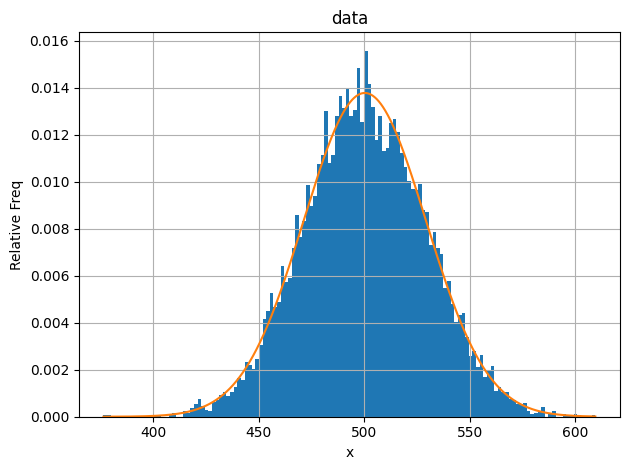

In [7]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=10000,numberSamples=100,lowLim=0,highLim=1000)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.01.png**

### 1. Type of Image
A histogram with a smooth curve overlaid, produced while testing the function `plotSimpleHistogram`.

### 2. Overall Summary
The figure shows a normalized histogram of a dataset with a smooth curve drawn on top. It provides a visual comparison between the empirical distribution and a continuous reference shape.

### 3. Detailed Description
- The histogram bars are **blue**, representing the relative frequency of data values along the x‑axis.  
- A smooth **orange** curve overlays the bars, allowing comparison between the observed distribution and a theoretical or smoothed distribution.  
- The **x‑axis** is labeled **“x”**, indicating the variable being measured.  
- The **y‑axis** is labeled **“Relative Freq”**, showing that the histogram is normalized.  
- The plot title is **“data”**, consistent with a simple functional test of the plotting routine.  
- The distribution appears roughly symmetric, centered near 500, with most values between approximately 400 and 600.

### 4. Purpose of the Image
The image verifies that `plotSimpleHistogram` correctly produces a normalized histogram and overlays a smooth curve. It also serves as an instructional example for students learning how histograms summarize data and how smooth curves can be used for comparison.

## Modifying the mean and the standard deviation

We can modify the mean, median, mode, and standard deviation of a dataset in a controlled manner through simple addition, subtraction, and multiplication. The next few examples will demonstrate this on a step-by-step basis.

(Note that these code samples all relate back to the original dataset.)

We will begin by creating a new dataset of 10,000 values containing the average of 512 samples taken from a population of uniformly distributed values between 0 and 1000. A histogram for the dataset is shown below along with printed values for the mean and the standard deviation.

***Note: In order to copy this code and run it under the Python interpreter, you will need to copy and paste the next four sections of code into the same Python source code file. You will also need to dismiss each plot from the screen to cause the next plot to appear.***

mean = 499.8389212033013
standard deviation = 12.644584358291358


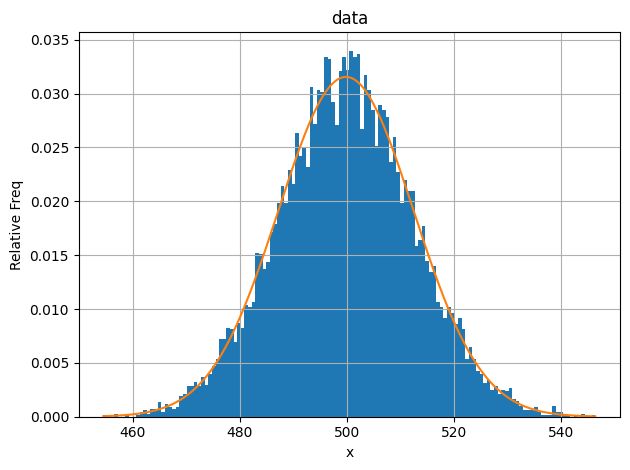

In [8]:
# Create a new dataset of 10000 values consisting of the average of 512 samples taken from a population of uniformly
# distributed values between 0 and 1000.
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=10000,numberSamples=512,lowLim=0,highLim=1000)

print("mean =",mean(data))
print("standard deviation =",stdev(data))
plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.02.png**

### 1. Type of Image
A relative-frequency histogram with an overlaid smooth curve, illustrating the distribution of a large simulated dataset and its approximate normal shape.

### 2. Overall Summary
The figure displays a histogram of a dataset formed from averages of many uniform samples, along with a smooth curve that closely follows the bars. The distribution is tightly concentrated around a central value near 500, visually reinforcing the idea that averaging many samples produces an approximately normal distribution with a specific mean and standard deviation.

### 3. Detailed Description
- **Histogram appearance:**  
  - The bars are **blue** and represent relative frequencies of the averaged data values.  
  - The bars form a single, prominent peak near the center of the x‑axis, with frequencies tapering off symmetrically on both sides.
- **Overlaid curve:**  
  - A smooth **orange** curve is drawn over the histogram.  
  - The curve closely tracks the tops of the bars, emphasizing how well the empirical distribution aligns with a normal‑shaped pattern.
- **Axes and scale:**  
  - The **x‑axis** is labeled **“x”** and spans approximately from **455** to **545**, reflecting the range of the averaged values.  
  - The **y‑axis** is labeled **“Relative Freq”**, with values from about **0.000** up to **0.035**, indicating that the histogram is normalized.
- **Title:**  
  - The plot is titled **“data”**, consistent with its role as a working figure tied to the underlying code example.

### 4. Purpose of the Image
This image supports the discussion of **modifying the mean and standard deviation** of a dataset constructed from many averaged samples. It visually demonstrates that the resulting distribution is tightly clustered and approximately normal, providing a concrete reference for the printed mean and standard deviation values in the surrounding code. Students can connect the numerical summaries (mean and standard deviation) to the shape, center, and spread of the histogram and its overlaid curve.

### Shift the mean

All that is necessary to change the mean of a dataset is to add a constant to or subtract a constant from every value in the dataset.

The following code shifts the mean for our dataset to 0 by subtracting the mean value from every value in the dataset. A histogram for the modified dataset is shown below with a new mean of 0 and no change in the standard deviation.

mean = -2.142428456863854e-14
standard deviation = 12.644584358291358


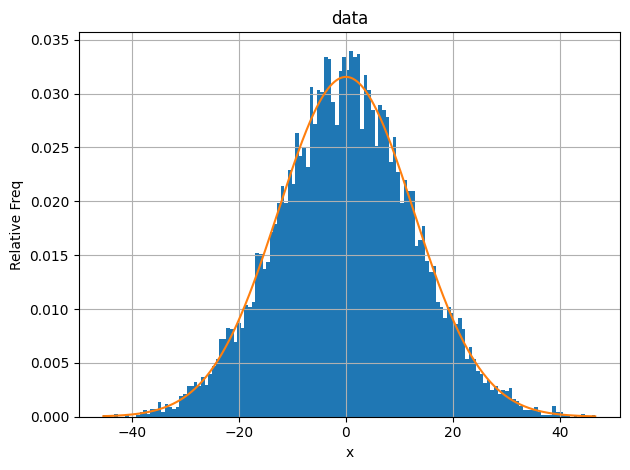

In [9]:
#Get the mean for the original dataset and subtract it from every value in the dataset.    
mu = mean(data)
for cnt in range(len(data)):
    data[cnt] -= mu

print("mean =",mean(data))
print("standard deviation =",stdev(data))
plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.03.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, illustrating the distribution of a dataset after its mean has been shifted to zero.

### 2. Overall Summary
The figure displays the relative‑frequency histogram of a dataset whose mean has been adjusted by subtracting the original mean from every value. The resulting distribution is centered at zero while retaining the same overall shape and standard deviation as the original dataset. A smooth curve is drawn over the histogram to highlight the distribution’s approximate normal form.

### 3. Detailed Description
- **Histogram bars:**  
  - Shown in **blue**, representing the relative frequencies of the shifted data values.  
  - The bars cluster symmetrically around **x = 0**, confirming that the mean shift was applied correctly.
- **Overlaid curve:**  
  - A smooth **orange** curve follows the general shape of the histogram.  
  - The curve peaks at zero and tapers symmetrically, reinforcing the normal‑like appearance of the transformed dataset.
- **Axes:**  
  - The **x‑axis** is labeled **“x”**, now spanning a range centered around zero.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating that the histogram is normalized.
- **Title:**  
  - The plot is titled **“data”**, consistent with the surrounding code examples.

### 4. Purpose of the Image
This image demonstrates the effect of shifting the mean of a dataset by subtracting the original mean from each value. It visually confirms that the mean becomes zero while the standard deviation and overall distribution shape remain unchanged. This supports the instructional point that adding or subtracting a constant affects only the mean, not the spread or form of the distribution.

### Modify the standard deviation

We can modify the standard deviation for a dataset by shifting the mean to zero and then multiplying every value in the dataset by a constant. After that, you can restore the original mean by adding the original mean value to every value in the dataset.

The following code will reduce the standard deviation by a factor of 2 by multiplying every value by 0.5. (In this case, the mean had already been shifted to zero.) You can see a histogram of the modified dataset below with the new standard deviation and no change in the current value of the mean.

mean = -1.071214228431927e-14
standard deviation = 6.322292179145679


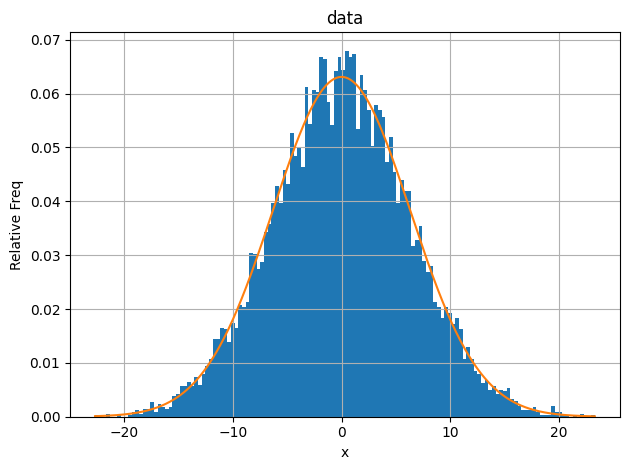

In [10]:
#Multiply each value by 0.5 to reduce sigma by a factor of two.
for cnt in range(len(data)):
    data[cnt] *= 0.5
    
print("mean =",mean(data))
print("standard deviation =",stdev(data))
plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.04.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, showing the distribution of a dataset after its standard deviation has been reduced through scaling.

### 2. Overall Summary
The figure displays the histogram of a dataset whose mean was previously shifted to zero and whose standard deviation was reduced by multiplying every value by 0.5. Although the underlying data have changed, the **visual appearance of the histogram remains the same** because the plotting function automatically adjusts the horizontal axis to match the new, narrower range. As a result, the distribution still appears centered and symmetric, but the x‑axis now reflects the reduced spread.

### 3. Detailed Description
- **Histogram bars:**  
  - Shown in **blue**, representing the relative frequencies of the scaled data values.  
  - The bars form a symmetric mound centered at **x = 0**, just as before the scaling.  
  - The overall shape is unchanged because the histogram is redrawn using the new, narrower data range.
- **Overlaid curve:**  
  - A smooth **orange** curve follows the same general shape as the histogram.  
  - The curve appears visually identical to earlier plots, but it is now aligned with the rescaled x‑axis.
- **Axes:**  
  - The **x‑axis** is labeled **“x”** and now spans a smaller numerical range, reflecting the reduced standard deviation.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating normalization.  
  - The vertical scale remains appropriate for the new distribution.
- **Title:**  
  - The plot is titled **“data”**, consistent with the surrounding examples.

### 4. Purpose of the Image
This image demonstrates that reducing the standard deviation by multiplying all values by a constant compresses the data horizontally but in this case did not change the visual appearance of the shape in the image.The histogram looks the same because the plotting function rescales the x‑axis automatically.

In the earlier image, the data spanned the area from -40 to +40. In this image, the data spans the area from -20 to +20.

The figure reinforces the instructional point that scaling affects the numerical spread of the data, not the visual form of the distribution when axes adjust accordingly.

### Shift the mean again

At this point, the mean for the dataset is still zero. We can change it to any value we choose by adding a constant to every value in the dataset. We will change the mean to -250 by subtracting 250 from every value in the dataset.

mean = -250.0
standard deviation = 6.322292179145679


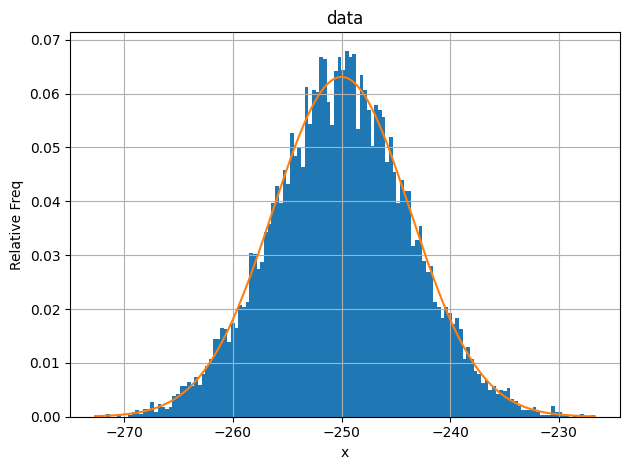

In [11]:
#Shift mu to -4250.
for cnt in range(len(data)):
    data[cnt] -= 250
    
print("mean =",mean(data))
print("standard deviation =",stdev(data))
plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.05.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, showing the distribution of a dataset after its mean has been shifted to a new value.

### 2. Overall Summary
The figure displays a histogram of a dataset whose mean had previously been zero and has now been shifted to **–250** by subtracting 250 from every value. The overall shape, spread, and appearance of the distribution remain unchanged; only the **horizontal position** of the distribution has moved. The smooth curve drawn over the histogram highlights the same distributional form, now centered at the new mean.

### 3. Detailed Description
- **Histogram bars:**  
  - Shown in **blue**, representing the relative frequencies of the shifted data values.  
  - The bars form a symmetric mound centered near **x = –250**, reflecting the new mean.  
  - The shape and height of the bars match the earlier histogram because shifting the mean does not affect the spread or form of the distribution.
- **Overlaid curve:**  
  - A smooth **orange** curve follows the same general shape as before.  
  - The curve is simply translated horizontally to align with the new center at –250.
- **Axes:**  
  - The **x‑axis** is labeled **“x”** and now spans a range centered around –250 beginning around -270 and ending around -230.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating normalization.  
  - The vertical scale remains unchanged because the distribution’s spread is unchanged.
- **Title:**  
  - The plot is titled **“data”**, consistent with the surrounding examples.

### 4. Purpose of the Image
This image demonstrates that shifting the mean by adding or subtracting a constant moves the entire distribution horizontally without altering its shape or standard deviation. It visually confirms that subtracting 250 from every value shifts the mean to –250 while preserving the distribution’s form, supporting the instructional point that mean shifts affect location but not spread.

### Summary of modifying the mean and standard deviation

By performing these simple steps, we began with a reasonably normal dataset having a mean of 499.83 and a standard deviation of 12.64 and transformed it into a reasonably normal dataset having a mean of -250.0 and a standard deviation of 6.32.

## Continuous distribution

Previous examples have mentioned a "normal" distribution. This section shows plots of a theoretical continuous distribution commonly referred to as a "normal" distribution or a "gaussian" distribution.

### The standard normal distribution

For purposes of review, the following code calls one of the utility methods defined earlier to plot a standard normal distribution from -3 standard deviations to +3 standard deviations. Students are not expected to understand the annotation code in this example at this point in the course, but will learn about annotating plots later in the course.

Note that the standard normal distribution has a mean value of zero and a standard deviation value of 1.0 as indicated in the following plot.

Note: Even though the following code, and much of the code in this eBook, uses textcoords='offset pixels', it is probably better to use textcoords='data' instead. Use of the latter will ensure better compatibility across a wide variety of display monitors having different resolutions. If the annotations in this example don't look correct to you, that may be the reason.

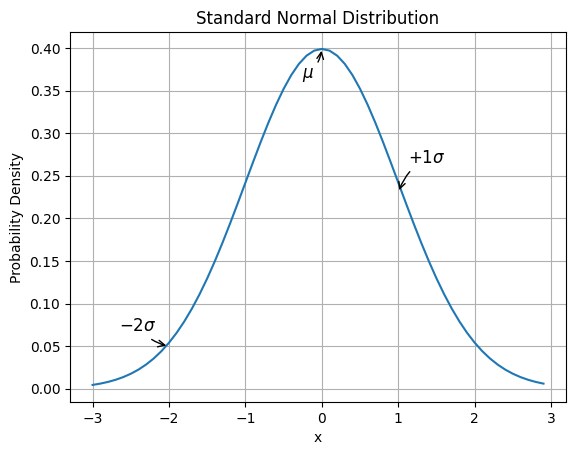

In [12]:
x = np.arange(-3,3,0.1)
y = [standardNormalDistribution(val) for val in x]

#Use matplotlib to plot the data.
plt.plot(x,y)
plt.grid(True)
plt.ylabel('Probability Density')
plt.xlabel('x')
plt.title('Standard Normal Distribution')

#Now add some annotation to the plot. Make things interesting by 
# rendering the annotation in LaTeX.
plt.annotate(r'$+1 \sigma$',
             xy=[1,0.23],xycoords='data',
             xytext=(+10, +30), textcoords='offset pixels', fontsize=12,
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))
plt.annotate(r'$-2 \sigma$',
             xy=[-2,0.05],xycoords='data',
             xytext=(-50, +15), textcoords='offset pixels', fontsize=12,
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))

plt.annotate(r'$\mu$',
             xy=[0,0.4],xycoords='data',
             xytext=(-20, -30), textcoords='offset pixels', fontsize=12,
             arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=.2"))
plt.savefig("StatisticsPart03.06.png")
plt.show()

## **Description of the image shown above, StatisticsPart03.06.png**

### 1. Type of Image
A plot of the **standard normal probability density function** with labeled annotations marking key standard‑deviation positions along the curve.

### 2. Overall Summary
The figure shows the familiar bell‑shaped curve of the standard normal distribution, extending from –3 to +3 standard deviations. The curve is centered at zero, where the mean of the distribution lies, and decreases symmetrically on both sides. Several annotations identify important reference points on the curve, supporting the review of standard‑normal properties.

### 3. Detailed Description
- **Curve:**  
  - A smooth, symmetric curve peaks at **x = 0**, representing the highest probability density.  
  - The curve tapers gradually toward both ends, approaching zero near **x = –3** and **x = +3**.
- **Annotations:**  
  - A label for **μ** appears at the peak of the curve at **x = 0**.  
  - A label for **–2σ** is placed on the left side of the curve near **x = –2**.  
  - A label for **+1σ** appears on the right side near **x = +1**.  
  - These annotations visually reinforce the meaning of standard‑deviation positions along the horizontal axis.
- **Axes:**  
  - The **x‑axis** is labeled **“x”** and spans from –3 to +3.  
  - The **y‑axis** is labeled **“Probability Density”**, indicating that the curve represents a probability density function rather than frequencies or counts.
- **Title:**  
  - The plot is titled **“Standard Normal Distribution”**, clearly identifying the distribution being shown.

### 4. Purpose of the Image
This image provides a visual review of the standard normal distribution, emphasizing its mean of zero and standard deviation of one. The annotations help students connect numerical concepts (μ, ±σ) to their graphical locations. The figure also sets the stage for later lessons on annotating plots, while reinforcing the foundational properties of the standard normal curve.

### Standardization: working with the Z-score

We can standardize a score on the x-axis of a normal distribution as follows:

Z = (x - mu)/sigma

#### Probability of a value less than 450 - theoretical

Create a dataset of 1000 normally distributed values in the range from 0 to 1000 and plot a histogram for the data.

Compute the Z-score for the value 450. Use the Z-score to find and print the probability that a value in the dataset will be less than 450. Express the probability as a decimal value, not as a percentage.

xBar = 500.1666185602021
stdev = 41.56617034378628
x = 450
z = -1.2069098053845966
probability that x is < 450 = 0.11373350613193489


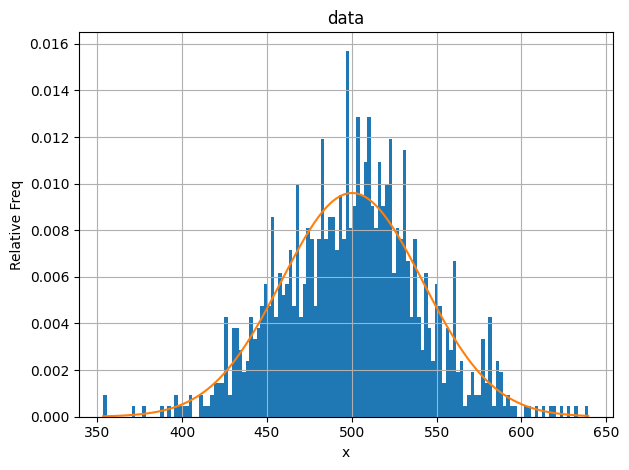

In [13]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=1000,numberSamples=49,lowLim=0,highLim=1000)

xBar = mean(data)
print("xBar =",xBar)
stDev = stdev(data)
print("stdev =", stDev)
x = 450
print("x =",x)

#Compute the Z-score
z = (x - xBar)/stDev
print("z =",z)

#Use the cumulative distribution to find the proportion of the area under the standard 
#normal distribution curve that is to the left of the value 450.
probability = cumulativeDistribution(z)
print("probability that x is < 450 =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.07.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, showing the distribution of a simulated dataset used to illustrate Z‑score standardization.

### 2. Overall Summary
The figure presents a histogram of 1000 normally distributed values generated within a range of 0 to 1000. A smooth curve is drawn over the bars to highlight the approximate normal shape of the dataset. This visualization supports the computation of a Z‑score for the value 450 and the corresponding theoretical probability that a randomly selected value from the dataset will fall below that point.

### 3. Detailed Description
- **Histogram bars:**  
  - Displayed in **blue**, representing the relative frequencies of the simulated data values.  
  - The bars form a bell‑shaped pattern centered near **x ≈ 500**, consistent with the sample mean of **500.1666**.
- **Overlaid curve:**  
  - Shown in **orange**, following the general shape of the histogram.  
  - The curve peaks near the sample mean and tapers symmetrically toward both ends of the x‑axis.
- **Axes:**  
  - The **x‑axis** is labeled **“x”** and spans roughly from **350** to **650**, capturing the central region of the distribution.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating that the histogram is normalized.
- **Title:**  
  - The plot is titled **“data”**, consistent with the surrounding examples and code demonstrations.

### 4. Purpose of the Image
This image supports the introduction of **Z‑score standardization**. Students compute the Z‑score for **x = 450** using the sample mean (**500.1666**) and sample standard deviation (**41.5662**), yielding **z = –1.2069**. The Z‑score is then used to determine the theoretical probability that a value from the dataset is less than 450, which in this example is **0.11373350613193489**. The histogram provides visual context for understanding where 450 lies relative to the center and spread of the distribution.

#### Probability of a value less than 450 - experimental

Confirm the probability that x is less than 450 by iterating through the actual data and counting the number of values that are less than 450. 

The results match very well with the theoretical value given above. This indicates that the normal probabilty density function can be used to predict the frequency of occurrence of values in this dataset.

probability that x is < 450 = 0.116


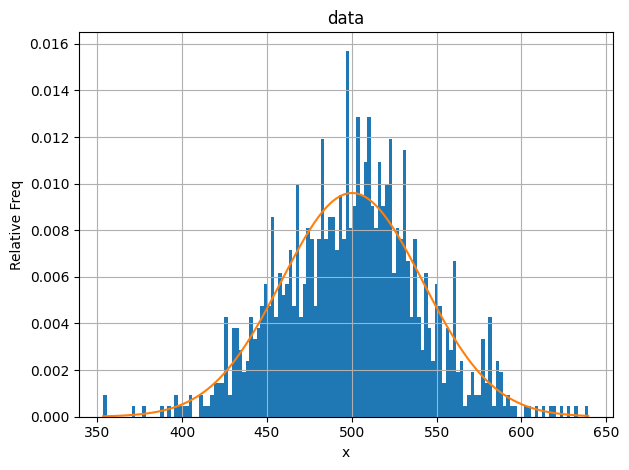

In [14]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=1000,numberSamples=49,lowLim=0,highLim=1000)
lt = 0
gte = 0
for val in data:
    if val < 450:
        lt += 1
    else:
        gte += 1
        
probability = lt/(lt + gte)
print("probability that x is < 450 =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.08.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, showing the empirical distribution of a dataset used to experimentally confirm a probability derived from a Z‑score calculation.

### 2. Overall Summary
The figure displays a histogram of 1000 normally distributed values, with a smooth curve drawn over the bars to highlight the approximate normal shape of the dataset. This visualization supports an **experimental check** of the probability that a value in the dataset is less than 450 by counting actual occurrences and comparing them to the theoretical probability computed earlier using the Z‑score.

### 3. Detailed Description
- **Histogram bars:**  
  - Shown in **blue**, representing the relative frequencies of the observed data values.  
  - The bars form a bell‑shaped pattern centered near **x ≈ 500**, consistent with the sample mean of **500.1666**.  
  - The distribution spreads across a range roughly from **350** to **650**.
- **Overlaid curve:**  
  - Displayed in **orange**, following the general shape of the histogram.  
  - The curve peaks near the sample mean and decreases symmetrically toward both ends, reinforcing the normal‑like appearance of the dataset.
- **Axes:**  
  - The **x‑axis** is labeled **“x”** and spans the central region of the distribution.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating that the histogram is normalized.
- **Title:**  
  - The plot is titled **“data”**, consistent with the surrounding examples.

### 4. Purpose of the Image
This image supports the **experimental verification** of the probability that a value in the dataset is less than 450. By iterating through the actual data and counting the number of values below 450, students confirm that the experimental probability closely matches the theoretical value derived from the Z‑score (**z = –1.2069**). The agreement between the two results (0.116 versus 0.113) demonstrates that the normal probability density function provides an accurate model for predicting frequencies in this dataset.

#### Probability of a value greater than 450 - theoretical

Create a dataset of 1000 normally distributed values in the range from 0 to 1000 and plot a histogram for the data.

Compute the Z-score for the value 450. Use the Z-score to find and print the probability that a value in the dataset will be greater than 450. Express the probability as a decimal value, not as a percentage.

xBar = 500.1666185602021
stdev = 41.56617034378628
x = 450
z = -1.2069098053845966
probability that x is > 450 = 0.8862664938680651


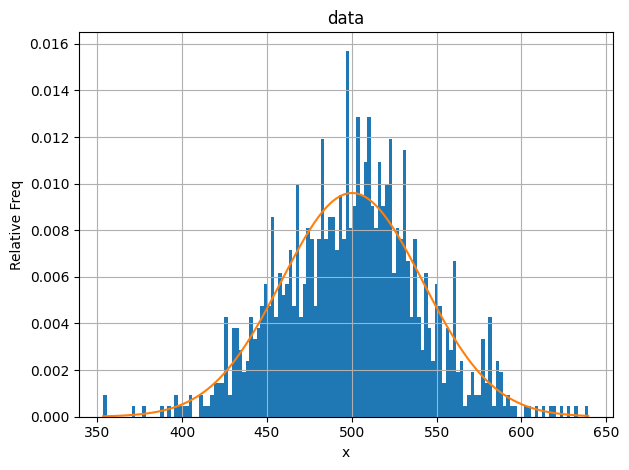

In [15]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=1000,numberSamples=49,lowLim=0,highLim=1000)

xBar = mean(data)
print("xBar =",xBar)
stDev = stdev(data)
print("stdev =", stDev)
x = 450
print("x =",x)

#Compute the Z-score
z = (x - xBar)/stDev
print("z =",z)

#Use the cumulative distribution to find the proportion of the area under the standard 
#normal distribution curve that is to the left of the value 450.
probability = cumulativeDistribution(z)
print("probability that x is > 450 =",1 - probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.09.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, illustrating the empirical distribution of a dataset used to compute the theoretical probability that a value is greater than 450.

### 2. Overall Summary
The figure shows a histogram of 1000 normally distributed values generated within a range of 0 to 1000. A smooth curve is drawn over the bars to highlight the approximate normal shape of the dataset. This visualization supports the theoretical calculation of the probability that a randomly selected value from the dataset exceeds 450, using the Z‑score derived from the sample mean and standard deviation.

### 3. Detailed Description
- **Histogram bars:**  
  - Displayed in **blue**, representing the relative frequencies of the simulated data values.  
  - The bars form a bell‑shaped pattern centered near **x ≈ 500**, consistent with the sample mean of **500.1666**.  
  - The distribution spans roughly from **350** to **650**, reflecting the dataset’s variability.
- **Overlaid curve:**  
  - Shown in **orange**, following the general shape of the histogram.  
  - The curve peaks near the sample mean and decreases symmetrically toward both ends, reinforcing the normal‑like appearance of the dataset.
- **Axes:**  
  - The **x‑axis** is labeled **“x”**, covering the central region of the distribution.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating that the histogram is normalized.  
- **Title:**  
  - The plot is titled **“data”**, consistent with the surrounding examples and code demonstrations.

### 4. Purpose of the Image
This image supports the **theoretical calculation** of the probability that a value from the dataset is greater than 450. Using the sample mean (**500.1666**) and standard deviation (**41.5662**), students compute the Z‑score (**z = –1.2069**) and then determine the probability that a value exceeds 450, which is **0.8862664938680651**. The histogram provides visual context for understanding where 450 lies relative to the center and spread of the distribution, reinforcing how Z‑scores relate to probabilities in a normal distribution.

#### Probability of a value greater than 450 - experimental

Confirm the probability that x is greater than 450 by iterating through the actual data and counting the number of values that are greater than 450. 

The results match very well with the theoretical value given above. This indicates that the normal probabilty density function can be used to predict the frequency of occurrence of values in this dataset.

probability that x is < 450 = 0.884


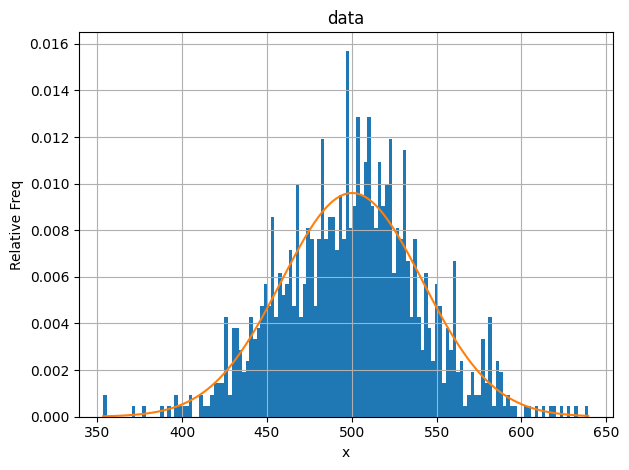

In [16]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=1000,numberSamples=49,lowLim=0,highLim=1000)
lt = 0
gte = 0
for val in data:
    if val < 450:
        lt += 1
    else:
        gte += 1
        
probability = gte/(lt + gte)
print("probability that x is < 450 =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.10.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, used to experimentally verify the probability that a value in the dataset is greater than 450.

### 2. Overall Summary
The figure shows a histogram of 1000 normally distributed values, with a smooth curve drawn over the bars to highlight the dataset’s approximate normal shape. This visualization supports an **experimental check** of the probability that a value exceeds 450 by counting actual occurrences in the dataset and comparing them to the theoretical probability computed earlier using the Z‑score.

### 3. Detailed Description
- **Histogram bars:**  
  - Displayed in **blue**, representing the relative frequencies of the observed data values.  
  - The bars form a bell‑shaped pattern centered near **x ≈ 500**, consistent with the sample mean of the dataset.  
  - The distribution spans roughly from **350** to **650**, reflecting the dataset’s variability.
- **Overlaid curve:**  
  - Shown in **orange**, following the general shape of the histogram.  
  - The curve peaks near the sample mean and decreases symmetrically toward both ends, reinforcing the normal‑like appearance of the dataset.
- **Axes:**  
  - The **x‑axis** is labeled **“x”**, covering the central region of the distribution.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating that the histogram is normalized.  
- **Title:**  
  - The plot is titled **“data”**, consistent with earlier examples.

### 4. Purpose of the Image
This image supports the **experimental verification** of the probability that a value in the dataset is greater than 450. By iterating through the actual data and counting how many values exceed 450, students confirm that the experimental probability (**0.884**) closely matches the theoretical value computed earlier (**0.886**). This agreement demonstrates that the normal probability density function provides a reliable model for predicting frequencies in this dataset.

#### Probability of a value less than 450 - theoretical for uniform distribution

Create a dataset of 1000 uniformly distributed values in the range from 0 to 1000 and plot a histogram for the data.

Compute the Z-score for the value 450. Use the Z-score to find and print the probability that a value in the dataset will be less than 450. Express the probability as a decimal value, not as a percentage.

xBar = 514.1370278623857
stdev = 289.53111943772905
x = 450
z = -0.2215203256456168
probability that x is < 450 = 0.41234369577373314


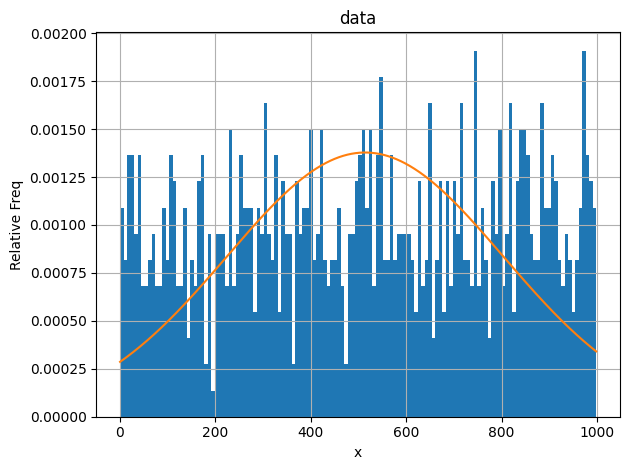

In [17]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=1000,numberSamples=1,lowLim=0,highLim=1000)

xBar = mean(data)
print("xBar =",xBar)
stDev = stdev(data)
print("stdev =", stDev)
x = 450
print("x =",x)

#Compute the Z-score
z = (x - xBar)/stDev
print("z =",z)

#Use the cumulative distribution to find the proportion of the area under the standard 
#normal distribution curve that is to the left of the value 450.
probability = cumulativeDistribution(z)
print("probability that x is < 450 =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.11.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, illustrating the empirical distribution of a uniformly generated dataset used to explore Z‑score calculations.

### 2. Overall Summary
The figure shows a histogram of 1000 values drawn from a **uniform distribution** between 0 and 1000. A smooth curve is drawn over the bars to provide a visual reference for the distribution’s shape. This visualization supports the theoretical calculation of the probability that a value from the dataset is less than 450, using the Z‑score computed from the sample mean and standard deviation.

### 3. Detailed Description
- **Histogram bars:**  
  - Displayed in **blue**, representing the relative frequencies of the uniformly distributed data values.  
  - The bars are spread broadly across the x‑axis, reflecting the wide variability typical of a uniform distribution.  
  - The distribution appears flatter and more dispersed than a normal distribution, consistent with the large standard deviation (**≈ 289.53**) relative to the range.
- **Overlaid curve:**  
  - The **orange curve** is a normal‑distribution curve, included to provide a smooth reference shape. It does not fit the dataset, since the underlying values come from a uniform distribution.
- **Axes:**  
  - The **x‑axis** is labeled **“x”** and spans the full range from **0 to 1000**, consistent with the uniform sampling interval.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating that the histogram is normalized.  
  - The vertical scale is low (up to about **0.002**) because the data are spread evenly across a wide range.
- **Title:**  
  - The plot is titled **“data”**, matching the surrounding examples.

### 4. Purpose of the Image
This image supports the **theoretical calculation** of the probability that a value from a uniform dataset is less than 450. Using the sample mean (**514.1370**) and standard deviation (**289.5311**), students compute the Z‑score (**z = –0.22152**) and determine the corresponding probability (**0.41234369577373314**). The histogram provides visual context for understanding how the value 450 compares to the center and spread of a uniform distribution, reinforcing how Z‑scores can be applied even when the underlying distribution is not normal.

#### Probability of a value less than 450 - experimental for uniform distribution

For the same dataset of 1000 uniformly distributed values in the range from 0 to 1000, confirm the probability that x is less than 450 by iterating through the actual data and counting the number of values that are less than 450. 

The probability results match surprisingly well with the theoretical value given above considering that the dataset does not have a normal distribution.

probability that x is < 450 = 0.432


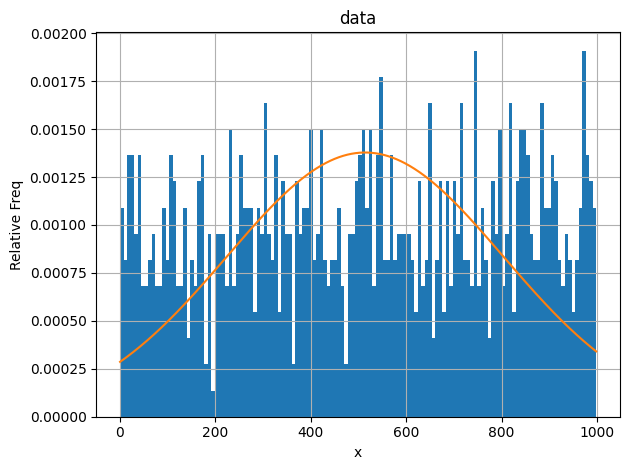

In [18]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=1000,numberSamples=1,lowLim=0,highLim=1000)
lt = 0
gte = 0
for val in data:
    if val < 450:
        lt += 1
    else:
        gte += 1
        
probability = lt/(lt + gte)
print("probability that x is < 450 =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.12.png**

### 1. Type of Image
A normalized histogram with an overlaid smooth curve, illustrating the empirical distribution of a uniformly generated dataset used to check a probability through direct counting.

### 2. Overall Summary
The figure shows a histogram of 1000 values drawn from a **uniform distribution** between 0 and 1000. A normal‑distribution curve is drawn over the bars to provide a smooth visual reference, even though it does **not** fit the data. This visualization supports an **experimental calculation** of the probability that a value from the dataset is less than 450 by counting actual occurrences.

### 3. Detailed Description
- **Histogram bars:**  
  - Shown in **blue**, representing the relative frequencies of the uniformly distributed data values.  
  - The bars are spread broadly across the x‑axis, reflecting the even spread of values typical of a uniform distribution.  
  - The distribution appears flat and wide, consistent with the large standard deviation relative to the range.
- **Overlaid curve:**  
  - The **orange** curve is a normal‑distribution curve included to provide a smooth reference shape.  
  - It does **not** fit the dataset, since the underlying values come from a uniform distribution.
- **Axes:**  
  - The **x‑axis** is labeled **“x”** and spans the full range from **0 to 1000**, matching the uniform sampling interval.  
  - The **y‑axis** is labeled **“Relative Freq”**, indicating that the histogram is normalized.  
  - The vertical scale is low (up to about **0.002**) because the data are evenly distributed across a wide range.
- **Title:**  
  - The plot is titled **“data”**, consistent with earlier examples.

### 4. Purpose of the Image
This image supports the **experimental verification** of the probability that a value from a uniform dataset is less than 450. By iterating through the actual data and counting the number of values below 450, students obtain an experimental probability of **0.432**, which matches surprisingly well with the theoretical value computed earlier. However this is misleading result. In general, the Z‑score probability estimate is not valid for a uniform distribution.

Although the dataset is uniformly distributed rather than normal, the experimental probability happens to fall close to the Z‑score‑based theoretical estimate. This occurs because the cutoff value lies near the center of the distribution, making the normal‑curve approximation numerically similar in this specific case, even though the normal model does not actually fit the data. In other words, this was not a good test of the concept. If we repeated the experiment with:
- a different cutoff (say 100 or 900), or
- a different uniform range, or
- a skewed distribution,
the Z‑score‑based probability would be wildly inaccurate.


#### Probability of a value within one sigma of the mean - theoretical

Find and print the probability that a value in the dataset will be within one sigma of the mean. Express the probability as a decimal value, not as a percentage.

xBar = 500.1666185602021
stdev = 41.56617034378628
xHigh = 541.7327889039884
zHigh = 1.000000000000001
xLow = 458.6004482164158
zLow = -0.9999999999999997
probability that x is within one sigma of the mean = 0.6826894723352726


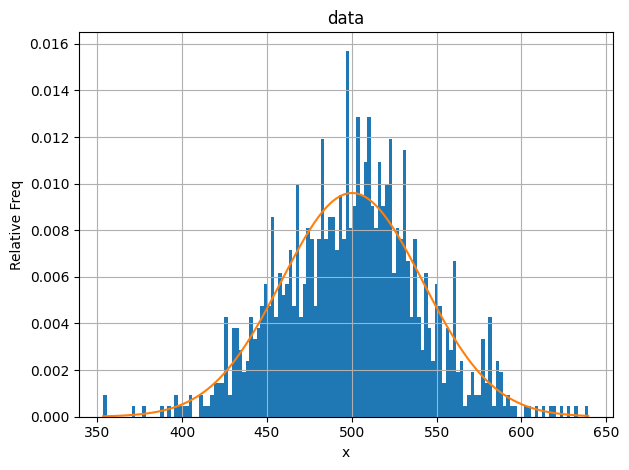

In [28]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=1000,numberSamples=49,lowLim=0,highLim=1000)

xBar = mean(data)
print("xBar =",xBar)
stDev = stdev(data)
print("stdev =", stDev)

xHigh = xBar + stDev
print("xHigh =",xHigh)
zHigh = (xHigh - xBar)/stDev
print("zHigh =",zHigh)

xLow = xBar - stDev
print("xLow =",xLow)
zLow = (xLow - xBar)/stDev
print("zLow =",zLow)

probability = cumulativeDistribution(zHigh) - cumulativeDistribution(zLow)
print("probability that x is within one sigma of the mean =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.13.png**

### Type of Image
Histogram with an overlaid smooth curve representing a fitted distribution, likely a normal curve, plotted against the relative frequency of observed data values.

### Overall Summary
The image displays a histogram of a dataset labeled “data,” showing how frequently different x‑values occur. A smooth orange curve is drawn over the bars to illustrate how the distribution of the data compares to a theoretical continuous distribution. The plot centers around a value near 500, with frequencies tapering off toward both lower and higher x‑values.

### Detailed Description
The histogram consists of blue bars representing relative frequencies along the y‑axis, labeled “Relative Freq.” The x‑axis is labeled “x” and spans approximately from the mid‑300s to the mid‑600s. The bars rise to a peak near the center of the distribution and decrease symmetrically on both sides. A smooth orange curve overlays the bars, following the general shape of the histogram and peaking near the same central x‑value. The title “data” appears at the top of the plot. 

### Purpose of the Image
This figure visually demonstrates the distribution of the dataset and how closely it aligns with a smooth theoretical curve. It supports instructional material on understanding empirical distributions, relative frequency, and how histograms relate to continuous probability models.

#### Probability of a value within one sigma of the mean - experimental

Confirm the probability that a value in the dataset will be within one sigma of the mean by iterating through the data and counting the number of values that are within plus or minus one sigma. The results match very well with those given above and indicate that the normal probabilty density function can be used to predict the frequency of occurrence of values in this dataset.

xBar = 500.1666185602021
stdev = 41.56617034378628
probability that x is within one sigma of the mean = 0.689


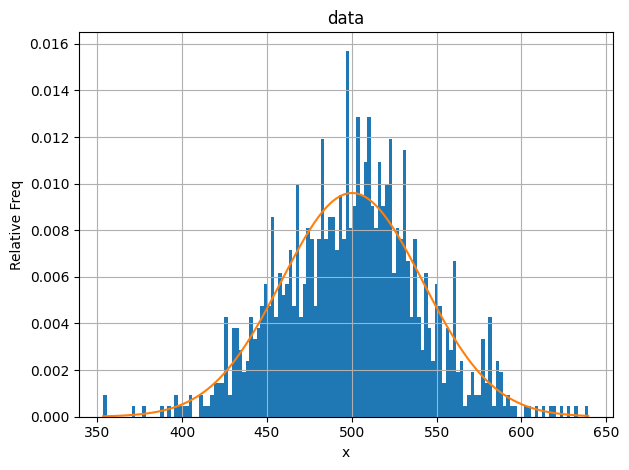

In [29]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=1000,numberSamples=49,lowLim=0,highLim=1000)

xBar = mean(data)
print("xBar =",xBar)
stDev = stdev(data)
print("stdev =", stDev)

inside = 0
outside = 0
for val in data:
    if (val > (xBar - stDev)) and (val < (xBar + stDev)):
        inside += 1
    else:
        outside += 1
        
probability = inside/(inside + outside)
print("probability that x is within one sigma of the mean =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.14.png**

### Type of Image
Histogram with an overlaid smooth curve representing a fitted continuous distribution, plotted using relative frequencies of observed data values.

### Overall Summary
The figure shows the empirical distribution of a dataset by displaying a histogram of relative frequencies across a range of x‑values. A smooth orange curve is drawn over the bars to illustrate how the observed data compare visually to a continuous distribution. The plot is centered near an x‑value of 500, with frequencies decreasing toward both ends of the range.

### Detailed Description
The histogram consists of blue bars whose heights represent relative frequencies along the y‑axis, labeled “Relative Freq.” The y‑axis ranges from 0.000 to approximately 0.016. The x‑axis is labeled “x” and spans values from roughly 350 to 650. The bars rise to a central peak and taper symmetrically on both sides. A smooth orange curve overlays the histogram, following the general shape of the bars and peaking near the same central region. The title “data” appears at the top of the plot. No additional annotations, markers, or numerical labels are present. The result (0.689) is a good match for the result (0.682) of the previous theoretical calculation.

### Purpose of the Image
This image visually confirms how the dataset is distributed and supports the experimental determination of the probability that values fall within one standard deviation of the mean. It helps readers connect the empirical histogram to the theoretical distribution used in probability calculations. 

#### Probability of a value greater than one sigma above the mean - theoretical

Find and print the probability that a value in the dataset will be greater one sigma above the mean. Express the probability as a decimal value, not as a percentage.

xBar = 500.0229676954646
stdev = 41.58210968881746
x = 541.605077384282
z = 0.9999999999999988
probability that x is greater than one sigma above the mean = 0.15865526383236406


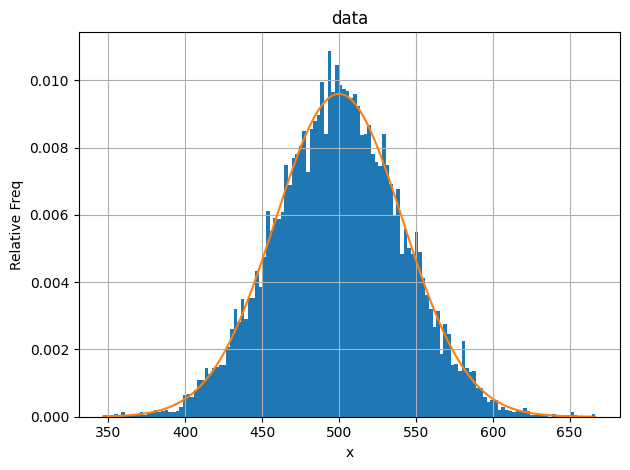

In [30]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=10000,numberSamples=49,lowLim=0,highLim=1000)

xBar = mean(data)
print("xBar =",xBar)
stDev = stdev(data)
print("stdev =", stDev)

x = xBar + stDev
print("x =",x)
z = (x - xBar)/stDev
print("z =",z)
probability = 1 - cumulativeDistribution(z)
print("probability that x is greater than one sigma above the mean =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.15.png**

### Type of Image
Histogram with an overlaid smooth curve representing a fitted continuous distribution, displayed using relative frequencies of observed data values.

### Overall Summary
The figure shows the empirical distribution of a dataset through a histogram of relative frequencies across a range of x‑values. A smooth orange curve is drawn over the bars to illustrate how the observed data compare visually to a continuous distribution. The distribution centers near an x‑value of about 500, with frequencies decreasing toward both lower and higher values.

### Detailed Description
The histogram is composed of blue bars whose heights represent relative frequencies along the y‑axis, labeled “Relative Freq,” ranging from 0.000 to approximately 0.010. The x‑axis is labeled “x” and spans values from roughly 350 to 650. The bars rise to a central peak and taper symmetrically on both sides. A smooth orange curve overlays the histogram, following the general shape of the bars and peaking near the same central region. The title “data” appears at the top of the plot. No additional annotations, markers, or numerical labels are present.

### Purpose of the Image
This image visually represents the distribution of the dataset and supports the computation of the probability that a value lies more than one standard deviation above the mean. It helps readers connect the empirical histogram to the theoretical distribution used in probability calculations.

#### Probability of a value greater than one sigma above the mean - experimental

Confirm the probability that a value in the dataset will be greater than one sigma above the mean by iterating through the data and counting the number of values that are greater than one sigma above the mean. The results match those given above very well and indicate that the normal probabilty density function can be used to predict the frequency of occurrence of values in this dataset.

xBar = 500.0229676954646
stdev = 41.58210968881746
probability that x is greater than one sigma above the mean = 0.1589


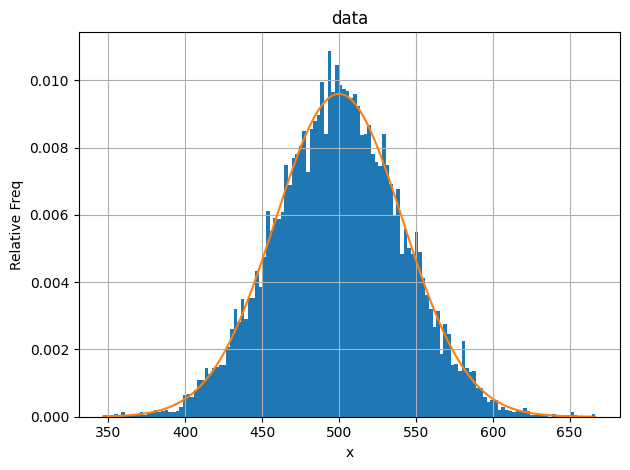

In [31]:
data = []
random.seed(1)
data = normalRandomGenerator(dataLength=10000,numberSamples=49,lowLim=0,highLim=1000)
xBar = mean(data)
print("xBar =",xBar)
stDev = stdev(data)
print("stdev =", stDev)

gt = 0
lte = 0
for val in data:
    if val > (xBar + stDev):
        gt += 1
    else:
        lte += 1
        
probability = gt/(gt + lte)
print("probability that x is greater than one sigma above the mean =",probability)

plotSimpleHistogram(data)

## **Description of the image shown above, StatisticsPart03.16.png**

### Type of Image
Histogram with an overlaid smooth curve representing a fitted continuous distribution, displayed using relative frequencies of observed data values.

### Overall Summary
The figure presents the empirical distribution of a dataset through a histogram of relative frequencies. A smooth orange curve is drawn over the bars to illustrate how the observed data compare visually to a continuous distribution. The distribution is centered near an x‑value of about 500, with frequencies decreasing toward both lower and higher values.

### Detailed Description
The histogram consists of blue bars whose heights represent relative frequencies along the y‑axis, labeled “Relative Freq,” ranging from 0.000 to approximately 0.010. The x‑axis is labeled “x” and spans values from roughly 350 to 650. The bars rise to a central peak and taper symmetrically on both sides. A smooth orange curve overlays the histogram, following the general shape of the bars and peaking near the same central region. The title “data” appears at the top of the plot. No additional annotations, markers, or numerical labels are present.

### Purpose of the Image
This image visually represents the distribution of the dataset and supports the experimental determination of the probability that a value lies more than one standard deviation above the mean. It helps readers connect the empirical histogram to the theoretical distribution used in probability calculations.

## The central limit theorem

### The population

Create a population dataset consisting of 49,000 uniformly distributed values ranging from 0 to 1000. Compute the mean, the median, and the population standard deviation of the data and plot a histogram of the data using matplotlib.

data length = 49000
mean = 500.1666185602021
median = 500.1474789149314
pstdev = 289.69815360800015


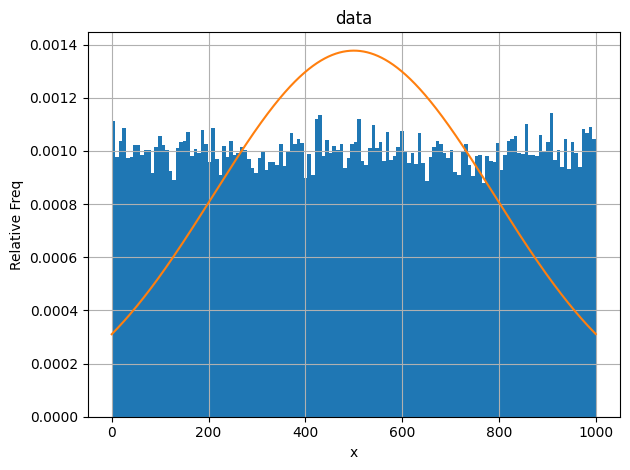

In [33]:
pop = normalRandomGenerator(dataLength=49000,numberSamples=1,lowLim=0,highLim=1000)

print("data length =",len(pop))
print("mean =",mean(pop))
print("median =",median(pop))
print("pstdev =", pstdev(pop))

plotSimpleHistogram(pop)

## **Description of the image shown above, StatisticsPart03.17.png**

### Type of Image
Histogram with an overlaid smooth curve representing a continuous distribution, plotted using relative frequencies for a large uniformly generated population.

### Overall Summary
The figure displays the distribution of a population dataset consisting of 49,000 uniformly distributed values between 0 and 1000. The histogram shows how frequently values occur across the full range, while a smooth orange curve is drawn over the bars to provide a visual comparison between the empirical distribution and a theoretical continuous model. The plot spans the entire interval from 0 to 1000, with relative frequencies remaining low and fairly even across the range.

### Detailed Description
The histogram is composed of blue bars representing relative frequencies along the y‑axis, labeled “Relative Freq,” which ranges from 0.0000 to approximately 0.0014. The x‑axis is labeled “x” and spans from 0 to 1000. The bars are distributed fairly uniformly across the full width of the plot, reflecting the uniform nature of the underlying dataset. A smooth orange curve overlays the histogram, rising gently toward the center of the range and tapering toward both ends. The title “data” appears at the top of the plot. No additional annotations, markers, or numerical labels are present.

### Purpose of the Image
This image illustrates the distribution of a large uniformly generated population and provides visual context for computing summary statistics such as the mean, median, and population standard deviation. It supports the introduction to the central limit theorem by showing the shape of the underlying population before sampling or further analysis.

### Average 49 samples from the population

Create the same dataset as before consisting of 49,000 uniformly distributed values ranging from 0 to 1000. Break the data into 49 samples of 1000 values each and average the samples to produce a single sample dataset of 1000 values. Compute the mean, the median, and the standard deviation of the data and plot a histogram of the data. Note that the histogram tends to be normal and the standard deviation is reduced by approximately 7, which is the square root of the number of samples (49). Also note that the mean and the median remain approximately the same as before. Thus the central limit theorem is confirmed.

This is the basis of the function named normalRandomGenerator that we have been using since early in the course to produce relatively normal datasets that were guaranteed to fall within a specified range of values.

data length = 1000
mean = 500.1666185602021
median = 501.48009792668023
stdev = 41.56617034378628


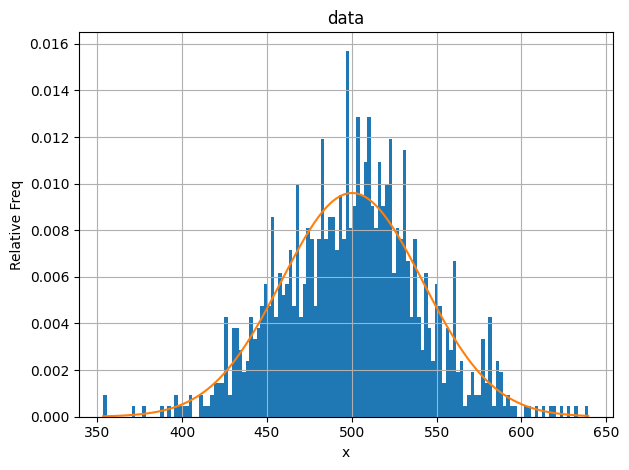

In [34]:
samp = normalRandomGenerator(dataLength=1000,numberSamples=49,lowLim=0,highLim=1000)

print("data length =",len(samp))
print("mean =",mean(samp))
print("median =",median(samp))
print("stdev =", stdev(samp))

plotSimpleHistogram(samp)

## **Description of the image shown above, StatisticsPart03.18.png**

### Type of Image
Histogram with an overlaid smooth curve representing a continuous distribution, plotted using relative frequencies for a dataset created by averaging multiple samples from a uniform population.

### Overall Summary
The figure displays the distribution of a dataset formed by dividing a uniformly distributed population of 49,000 values into 49 samples of 1,000 values each and averaging those samples to produce a new dataset of 1,000 averaged values. The histogram shows how these averaged values are distributed, and the overlaid smooth curve illustrates how closely the resulting distribution resembles a normal distribution. The plot centers near an x‑value of 500, with frequencies tapering toward both ends, reflecting the reduced variability produced by averaging.

### Detailed Description
The histogram consists of blue bars representing relative frequencies along the y‑axis, labeled “Relative Freq,” ranging from 0.000 to approximately 0.016. The x‑axis is labeled “x” and spans values from roughly 350 to 650. The bars rise to a central peak near 500 and taper symmetrically on both sides. A smooth orange curve overlays the histogram, following the same general shape and peaking near the center. The title “data” appears at the top of the plot. No additional annotations, markers, or numerical labels are present.

### Purpose of the Image
This image demonstrates how averaging multiple samples from a uniform population produces a distribution that is approximately normal with a reduced standard deviation. It visually supports the central limit theorem and shows why the averaging process used in the normalRandomGenerator function yields datasets that are both approximately normal and constrained within a specified range.

## Solving a sampling problem

***Note: In order to copy this code and run it under the Python interpreter, you will need to copy and paste the next two sections of code into the same Python source code file. You will also need to dismiss each plot from the screen to cause the next plot to appear.***

Problem: We have a population containing 49,000 values that is known to have a population sigma of 289.69. We need to extract a sample from that population containing at least 1000 values that will have a sigma in the range of 47 to 49. Write a program to accomplish that and display the mean, median, sigma, and a histogram of the original population and the resulting sample.

First gather statistics and display a histogram of the raw data.

population data length = 49000
mean = 500.1666185602021
median = 500.1474789149314
pstdev = 289.69815360800015

Display the histogram of the population


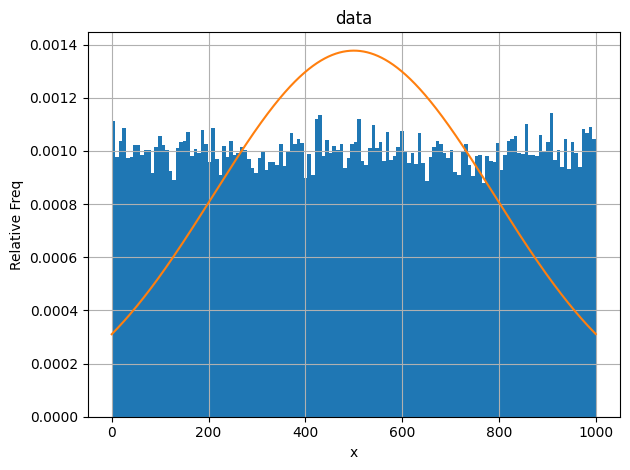

In [35]:
#Create the population
pop = normalRandomGenerator(dataLength=49000,numberSamples=1,lowLim=0,highLim=1000)

#Get and display statistics
print("population data length =",len(pop))
print("mean =",mean(pop))
print("median =",median(pop))
print("pstdev =", pstdev(pop))
print()
print("Display the histogram of the population")
plotSimpleHistogram(pop)

## **Description of the image shown above, StatisticsPart03.19.png**

### Type of Image
Histogram with an overlaid smooth curve representing a continuous distribution, plotted using relative frequencies for a large uniformly generated population.

### Overall Summary
The figure shows the distribution of a population dataset consisting of 49,000 uniformly distributed values between 0 and 1000. The histogram displays how frequently values occur across the full range, while a smooth orange curve is drawn over the bars to provide a visual comparison between the empirical distribution and a theoretical continuous model. The distribution is broad and relatively flat compared to a normal distribution, reflecting the uniform nature of the underlying data.

### Detailed Description
The histogram is composed of blue bars representing relative frequencies along the y‑axis, labeled “Relative Freq,” which ranges from 0.0000 to approximately 0.0014. The x‑axis is labeled “x” and spans from 0 to 1000. The bars extend across the entire width of the plot, with modest variation in height, consistent with a uniform distribution. A smooth orange curve overlays the histogram, rising toward the center of the range and tapering toward both ends. The title “data” appears at the top of the plot. No additional annotations, markers, or numerical labels are present.

### Purpose of the Image
This image provides a visual representation of the raw population data before sampling. It supports the problem context by showing the distribution from which a sample must be extracted and by illustrating the population’s mean, median, and population standard deviation. The figure establishes the baseline characteristics needed for the subsequent task of generating a sample with a much smaller standard deviation.

Now create the sample and display its statistics.

targetSigma = 48
numberVal = 36
Extract and average the required number of values from the population
data length = 1361
mean = 500.1831497564537
median = 501.6711738735864
stdev = 48.238469890954576


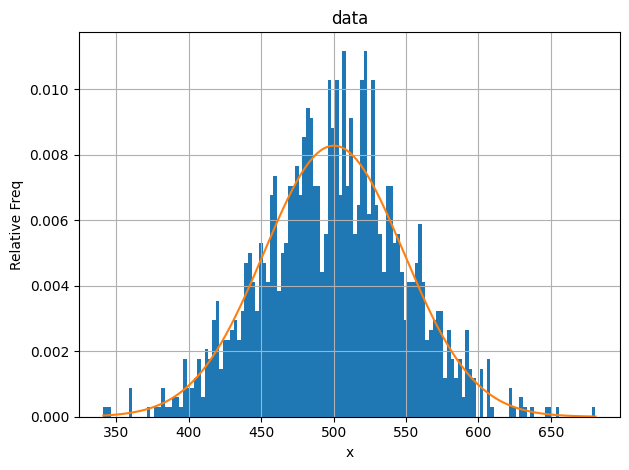

In [36]:
#Compute the number of values that must be averaged to produce the sample dataset
#with the required statistics.
targetSigma = 48
print("targetSigma =",targetSigma)
numberVal = (round(pstdev(pop)/targetSigma))**2
print("numberVal =",numberVal)
sampleLength = len(pop)//numberVal
sampAvg = []

print("Extract and average the required number of values from the population")
sampAvg = normalRandomGenerator(dataLength=sampleLength,numberSamples=numberVal,lowLim=0,highLim=1000)

#Display the statistics of the new dataset
print("data length =",len(sampAvg))
print("mean =",mean(sampAvg))
print("median =",median(sampAvg))
print("stdev =", stdev(sampAvg))

#Display the histagram
plotSimpleHistogram(sampAvg)

## **Description of the image shown above, StatisticsPart03.20.png**

### Type of Image
Histogram with an overlaid smooth curve representing a continuous distribution, plotted using relative frequencies for a sampled and averaged dataset.

### Overall Summary
The figure displays the distribution of a sample created by extracting values from a larger population and averaging groups of values to achieve a target standard deviation near 48. The histogram shows how the resulting sample values are distributed, while a smooth orange curve overlays the bars to illustrate how closely the sample resembles a normal distribution. The plot is centered near a value of 500, with frequencies tapering toward both lower and higher x‑values.

### Detailed Description
The histogram consists of blue bars whose heights represent relative frequencies along the y‑axis, labeled “Relative Freq.” The x‑axis is labeled “x.” The bars form a single central peak and decrease in height on both sides, giving the distribution a bell‑shaped appearance. A smooth orange curve overlays the histogram, following the general shape of the bars and peaking near the same central region. The title “data” appears at the top of the plot. No additional annotations, gridlines, or numerical tick labels are explicitly shown in the image.

### Purpose of the Image
This image illustrates the distribution of a sample constructed to have a standard deviation close to a specified target while preserving the original population’s mean. It supports the explanation of how averaging selected values from a broader population can produce a dataset with reduced variability and an approximately normal distribution, suitable for demonstrating controlled sampling and variance reduction.

#### --To be continued in the tutorial titled Statistics Exercises Part 4--

Author: Prof. Richard G. Baldwin, Austin Community College, Austin, TX

File: StatisticsPart03.ipynb

Revised: 03/03/26

Copyright 2018 Richard G. Baldwin

-end-
